# The notebooks includes the process of feature selection


## This code sets up the environment for data handling, visualization, and using a machine learning model to score the importance of data features.

### 1. Unique Commands & System Setup

 * **`warnings.filterwarnings("ignore")`:** **Output Cleaner.** A Python command that hides less critical warning messages for a cleaner console display.
 * **`%matplotlib inline`:** **Plot Display.** A special command for **Jupyter notebooks** ensuring that all generated charts and graphs are shown immediately below the code cell.

---

### 2. Machine Learning for Feature Selection

 * **`train_test_split`:** **Data Splitter.** Used to divide your dataset into separate parts for training and testing a model.
 * **`RandomForestClassifier`:** **Importance Scorer.** This is a machine learning model chosen because it can calculate and rank the **importance score** of every feature in your dataset.

In [2]:
import os # For managing file paths and directories.
import matplotlib.pyplot as plt # For plotting and visualization.
import geopandas # For handling geospatial vector data (although not directly used here).
import pandas as pd # For data manipulation and DataFrame operations.
import seaborn as sn # For high-level statistical data visualization (used for heatmaps and pairplots).
import numpy as np # For numerical operations, especially with arrays.
import warnings # For warning management.
warnings.filterwarnings("ignore") # Suppress warnings for cleaner output.
%matplotlib inline 
# Jupyter command to display plots directly below the code cell.

from sklearn.model_selection import train_test_split # Import for splitting data.
from sklearn.ensemble import RandomForestClassifier # Import the Random Forest model (used for calculating feature importance).

Setting the directory

In [3]:
os.chdir(r'/workspace/VY') # Set the current working directory to the VY training area.

Reading the .csv file with predictor variables and target variable

In [4]:
data=pd.read_csv('sample_points.csv') # Load the pre-processed sample points data, which includes all features and the 'Landslide' label.

## Correlation Matrix

Plotting the correlation matrix to check the linear relation between our predictors

In [7]:
df = data.iloc[:, :-1] # Create a DataFrame 'df' containing only the predictor features (excluding the last column, the target label).
# generating correlation matrix
corr = df.corr(method='pearson') # Calculate the Pearson correlation matrix (linear relationship) between all predictor variables.

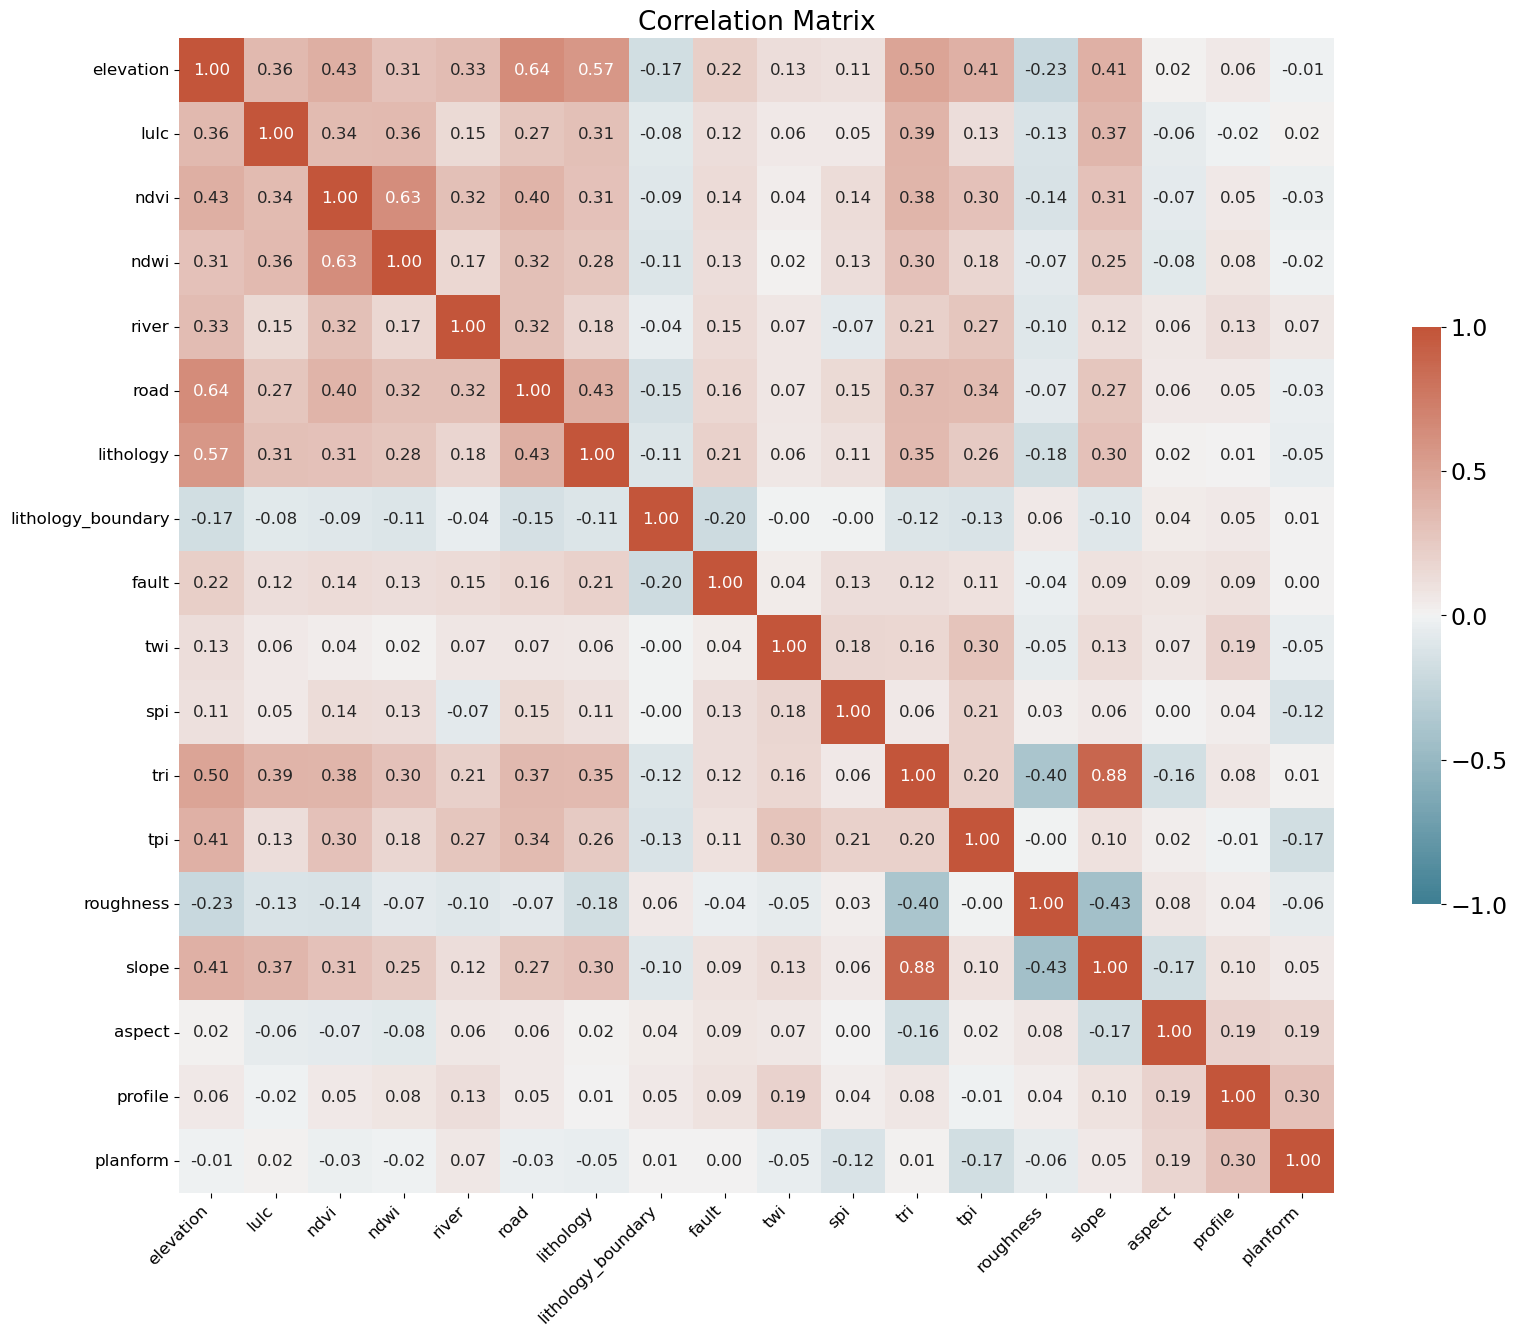

In [8]:
# Calculate correlation matrix
df = data.iloc[:, :-1] # Select features again.
corr = df.corr(method='pearson') # Calculate correlation matrix again.

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(20, 15)) # Create a large figure for better visibility.

# Create the heatmap with adjusted font sizes
ax = sn.heatmap(
    corr, 
    annot=True, # Display the correlation values (coefficients) on the heatmap cells.
    fmt='.2f', # Format the displayed values to two decimal places.
    vmin=-1, vmax=1, center=0, # Set the color scale limits from -1 (perfect negative correlation) to 1 (perfect positive correlation), centered at 0.
    cmap=sn.diverging_palette(220, 20, n=200), # Use a diverging color palette (colors change based on positive/negative values).
    square=True, # Ensure the cells are square.
    annot_kws={"size":12}, # Set the font size for the correlation coefficients displayed inside the heatmap.
    cbar_kws={"ticks": [-1, -0.5, 0, 0.5, 1], "shrink": 0.5}, # Configure the color bar (ticks and size).
)

# Set x and y labels font size
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45, # Rotate x-axis labels for readability.
    horizontalalignment='right',
    fontsize=12 
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=12
)

# Set the title font size
ax.set_title('Correlation Matrix', fontsize=19)

# Set the font size for color bar labels
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=17)

plt.savefig(r'/workspace/fig/VY/correlation.png', bbox_inches='tight', dpi=600) # Save the correlation matrix plot.
plt.show() # Display the plot.

We can see, that there are several variables that are highly correlated, especially the climate data. Let's remove some of them

In [9]:
# The below code shows all columns that are more correlated that a given threshold
# Function to identify columns (features) with high correlation to others, exceeding a specified cutoff.
def test_correlation(df, cutoff=0.75):
    abs_corr = df.corr().abs() # Calculate the absolute value of the correlation matrix.
    upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool)) # Select the upper triangle of the matrix (excluding the diagonal). This prevents self-correlation and duplicate pairs.
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > cutoff)] # Collect columns that have *any* correlation greater than the cutoff (0.75) in the upper triangle.
    return to_drop

# Print the columns to drop
test_correlation(df) # Execute the function with the default cutoff of 0.75.

['slope']

In [10]:
data_selected = data.drop(columns=['tpi']) #Drop highly correlated predictors

Showing the first 5 rows of the data to see that the columns are removed

In [11]:
data_selected.head()

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,tri,roughness,slope,aspect,profile,planform,Landslide
0,3.77,0.56,1.07,1.02,1.41,3.57,0.41,17.25,0.78,1.13,1.09,1.32,1.63,1.57,1.06,1.00,0.83,1
1,3.77,4.47,2.39,1.86,1.01,3.57,1.12,1.24,0.78,1.13,1.09,2.72,1.26,3.34,0.88,0.98,1.12,1
2,0.93,2.88,1.07,1.02,1.26,0.20,0.41,17.25,0.78,1.13,1.14,1.32,0.61,1.57,0.69,0.98,1.12,1
3,3.77,0.00,2.39,1.86,1.26,3.57,0.41,0.13,0.78,1.13,1.09,0.58,1.63,1.57,1.06,1.06,1.12,1
4,3.77,2.88,1.07,1.86,1.41,3.57,3.22,0.13,0.78,1.13,1.09,0.58,1.63,0.39,1.25,0.98,1.12,1


Plotting a new correlation matrix without highly correlated features

In [12]:
def correlation_matrix(df):
    # Function to plot a correlation matrix, hiding the redundant lower triangle and diagonal.
    corr = df.corr(method='pearson')
    mask = np.triu(np.ones_like(corr, dtype=bool)) # Create a mask to hide the upper triangle (mask=True hides the data).

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))

    # Generate a custom diverging colormap
    cmap = sn.diverging_palette(230, 20, as_cmap=True)

    sn.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}) # Plot the heatmap.

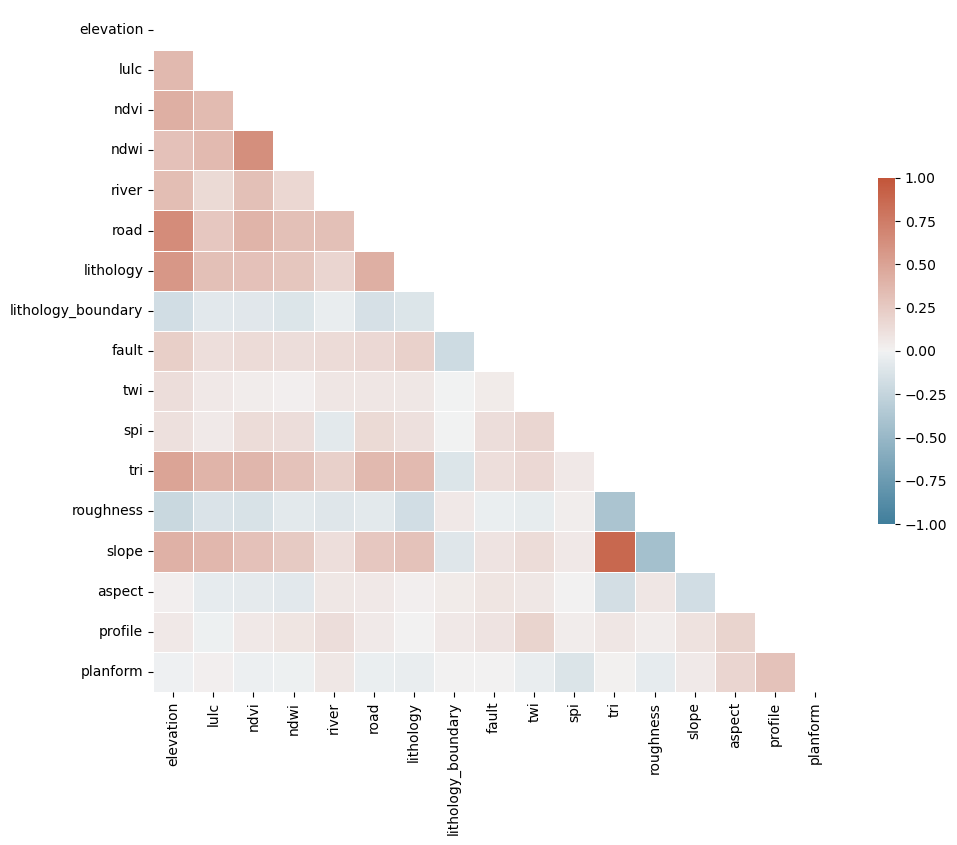

In [13]:
# Print the correlation matrix
# Plot the correlation matrix for the new, reduced dataset (excluding the label column).
correlation_matrix(data_selected.iloc[:,0:-1])

Plotting the distributions of the selected features

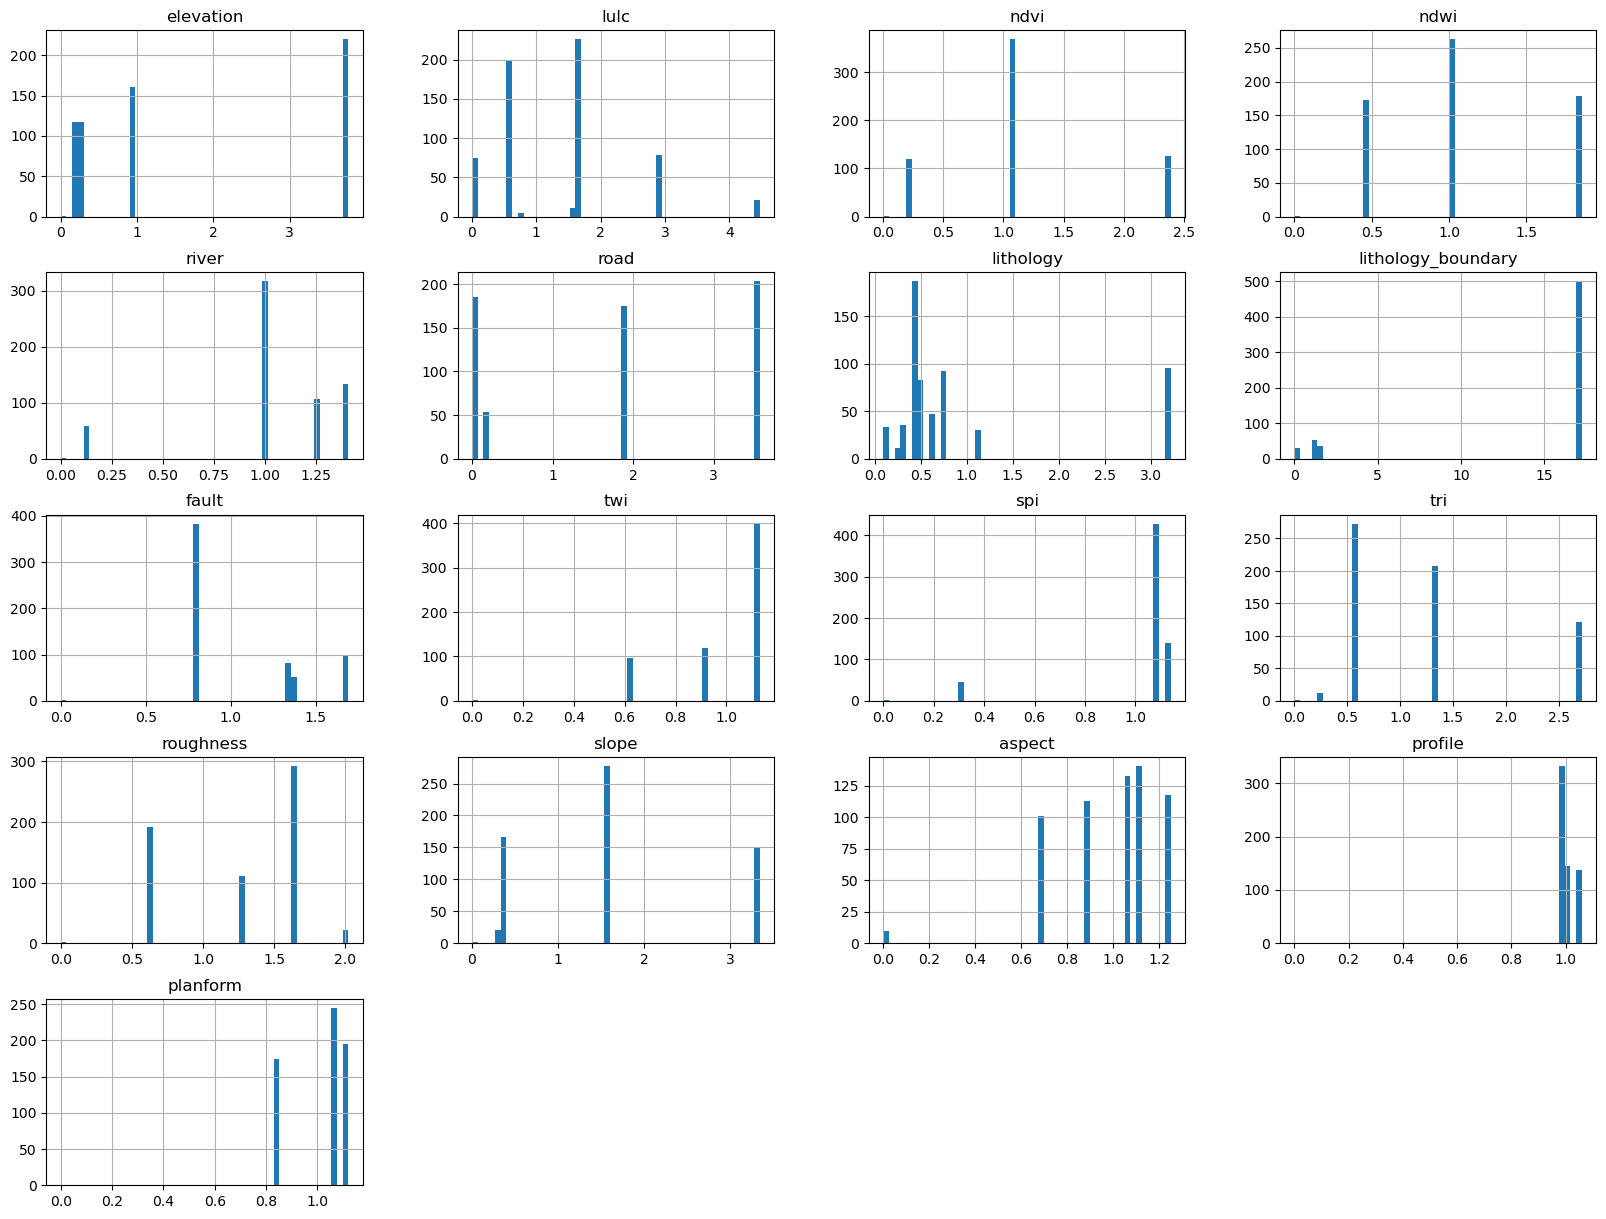

In [14]:
# Plot histograms for all remaining predictor variables to visualize their distribution shapes.
data_selected.iloc[:,0:-1].hist(bins=50, figsize=(20,15))
plt.show()

And their pairwise scatter plot


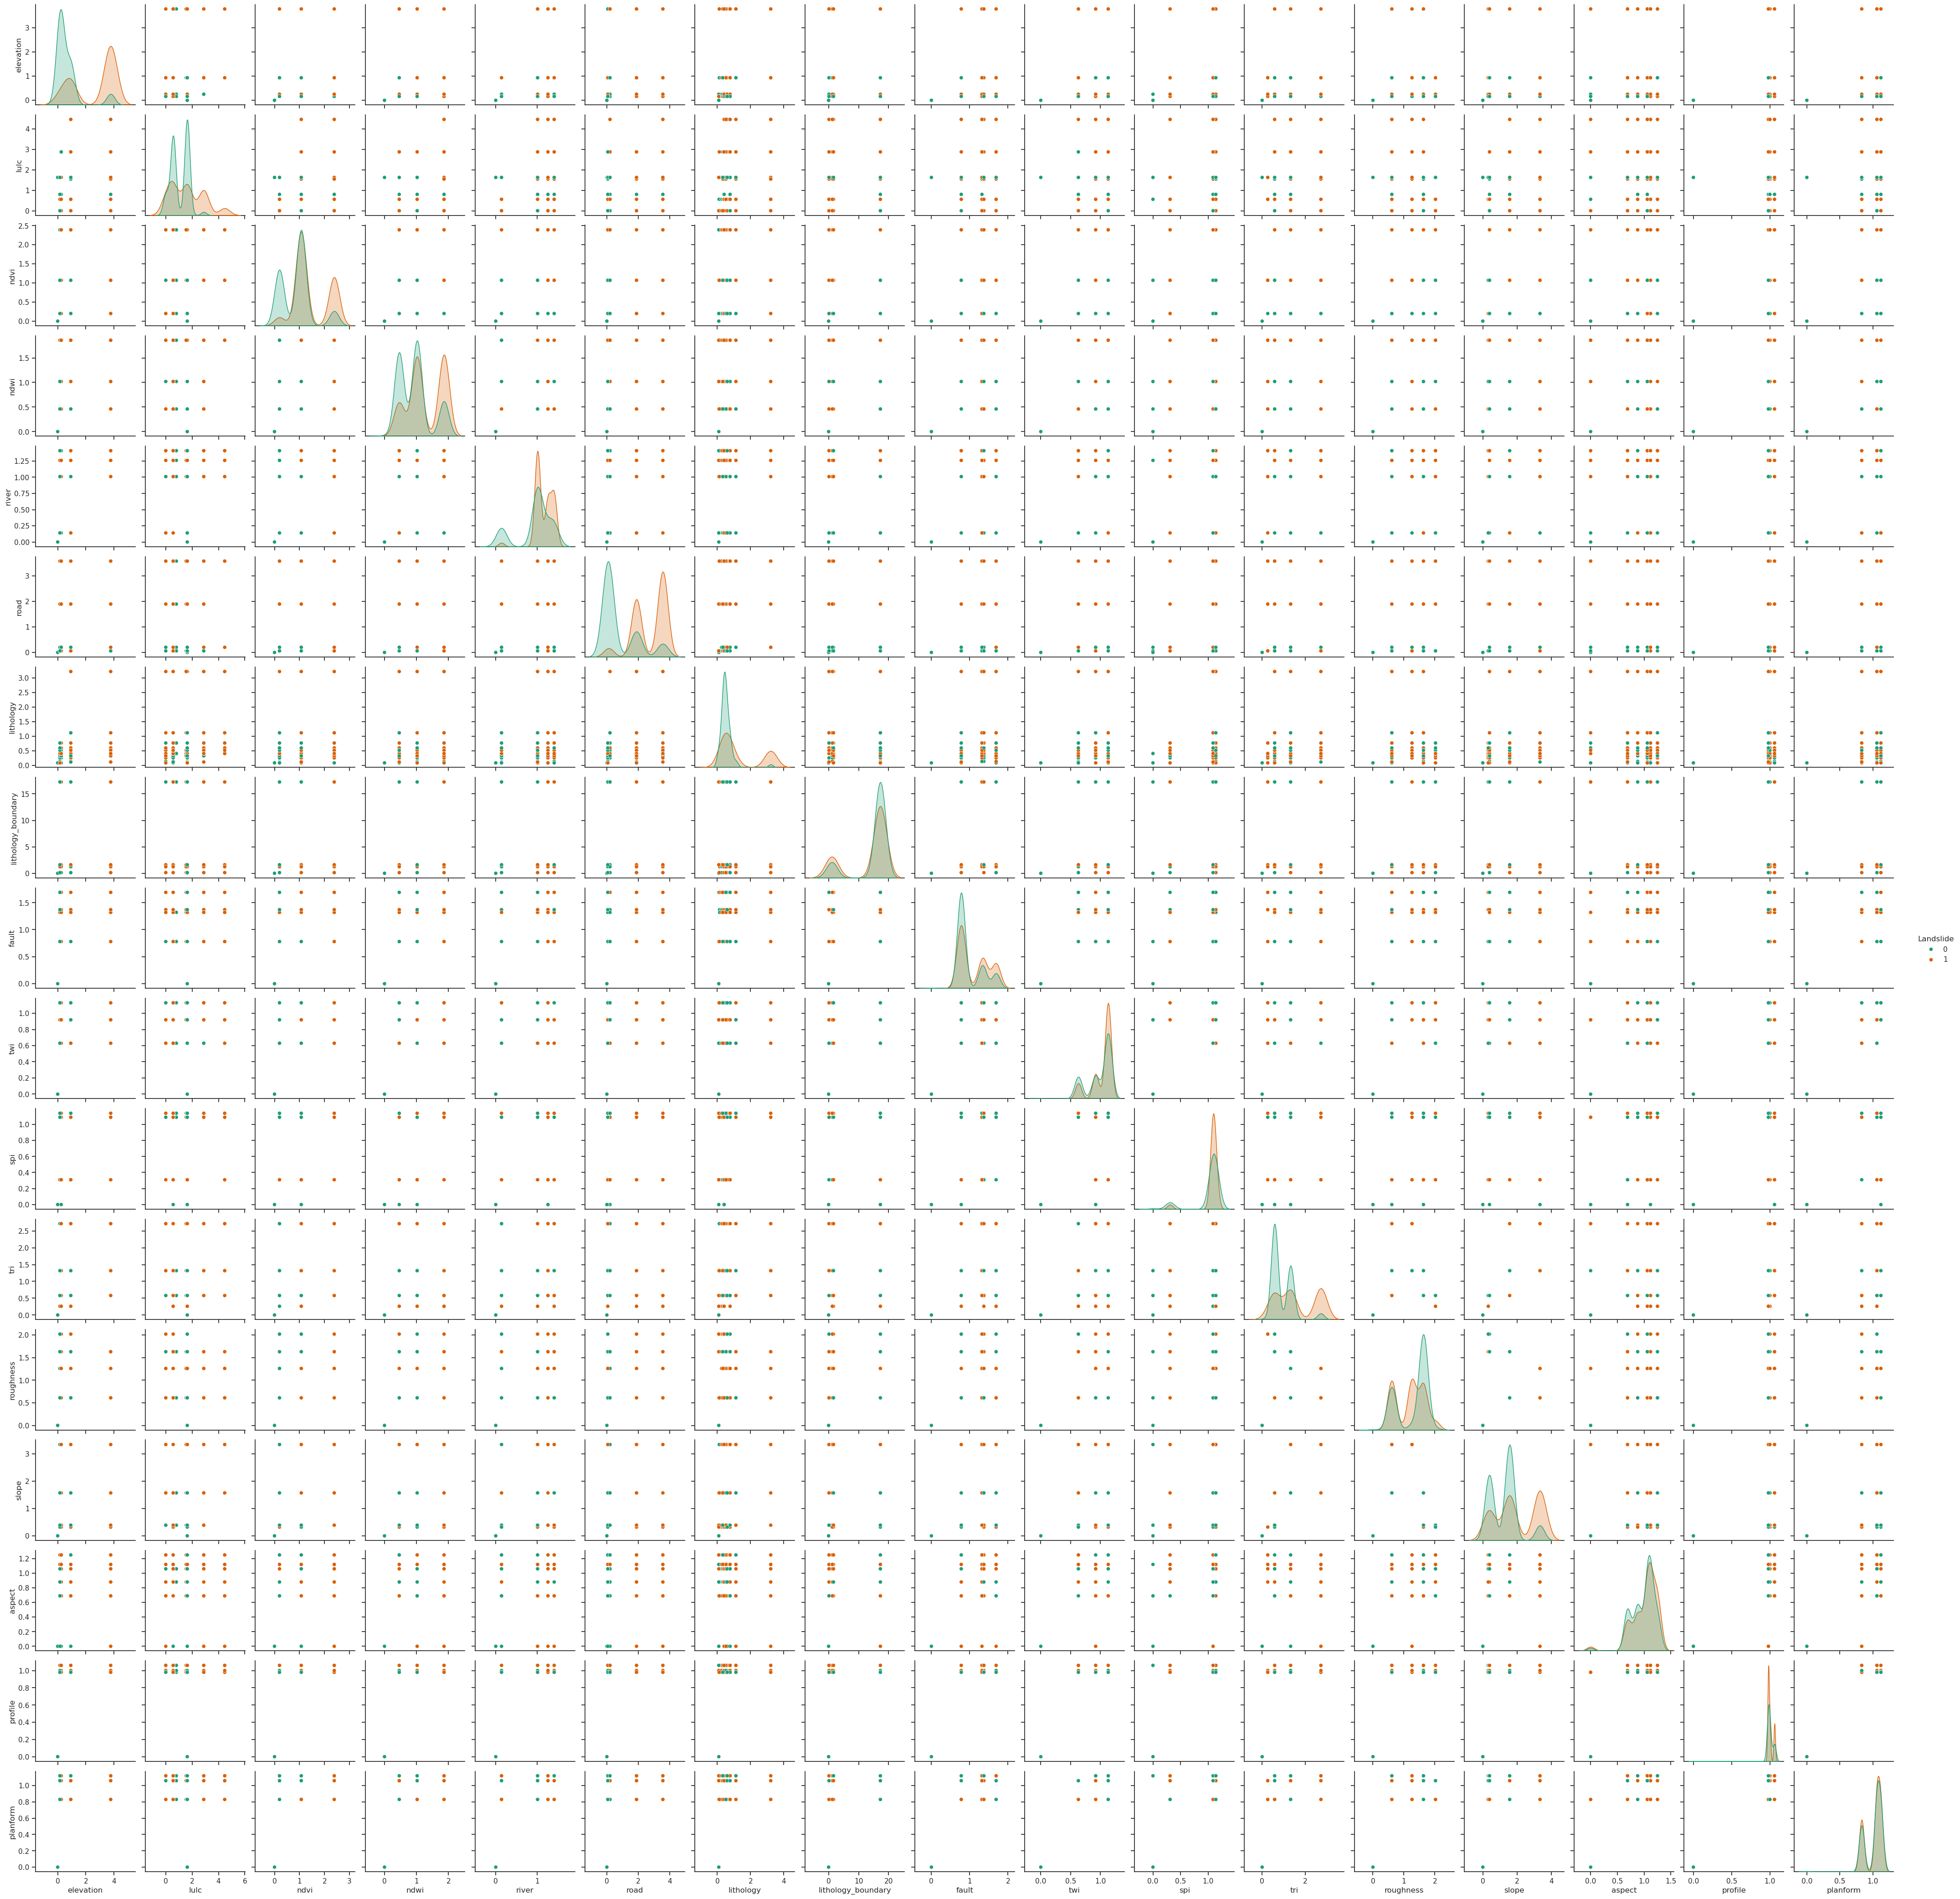

In [16]:
sn.set_theme(style="ticks")
# Generate a pairwise scatter plot (matrix plot) of all features against each other, colored by the 'Landslide' class.
# This helps visually identify non-linear relationships and how features separate the classes.
sn.pairplot(data_selected, hue="Landslide", palette='Dark2')

# Feature selection with the help of Random Forest

In [17]:
from sklearn.model_selection import train_test_split # Import for splitting data.
from sklearn.ensemble import RandomForestClassifier # Import the Random Forest model (used for calculating feature importance).

In [18]:
X = data.iloc[:, 0:-1] # Select all original features (before correlation-based removal).

In [19]:
X[:3]

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,tri,tpi,roughness,slope,aspect,profile,planform
0,3.77,0.56,1.07,1.02,1.41,3.57,0.41,17.25,0.78,1.13,1.09,1.32,0.37,1.63,1.57,1.06,1.00,0.83
1,3.77,4.47,2.39,1.86,1.01,3.57,1.12,1.24,0.78,1.13,1.09,2.72,0.15,1.26,3.34,0.88,0.98,1.12
2,0.93,2.88,1.07,1.02,1.26,0.20,0.41,17.25,0.78,1.13,1.14,1.32,0.15,0.61,1.57,0.69,0.98,1.12


In [20]:
y = data["Landslide"] # Select the target variable.

In [21]:
y[:3]

0    1
1    1
2    1
Name: Landslide, dtype: int64

Splitting our data into a training (70% of the data) and a testing set (30%), stratified after classes, so that we get the same amount of landslide and non-landslide samples in both sets


In [22]:
# Split X and y into training (70%) and testing (30%) sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # Initial split using a 30% ratio 

# It is also possible to manually split the dataset into training data and testing:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=[type here], random_state=42, stratify=y) # Final split using a fixed number of samples for the test set, ensuring class balance (stratify=y)

In [23]:
classifier = RandomForestClassifier(random_state=42) # Initialize the Random Forest model.

In [24]:
classifier.fit(X_train, y_train) # Train the RF model on the training data.
y_pred = classifier.predict(X_test) # Use the trained model to predict classes on the test data.

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix # Import for displaying confusion matrix.
print(confusion_matrix(y_test, y_pred)) # Print the raw confusion matrix.

[[78 15]
 [19 73]]


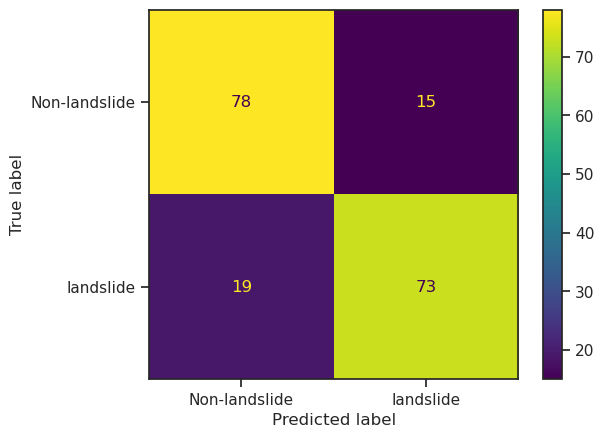

In [26]:
# Plot the confusion matrix using the updated function.
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, display_labels=["Non-landslide", "landslide"]) 
plt.show()

In [31]:
from sklearn.metrics import accuracy_score # Duplicate import
print(accuracy_score(y_test, y_pred)) # Print the overall accuracy score

0.8162162162162162


In [33]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, y_pred)) # Print Cohen's Kappa score for RF

0.632335749357026


## Feature Imporance Analysis

Plotting the graph showing which features are important for the model

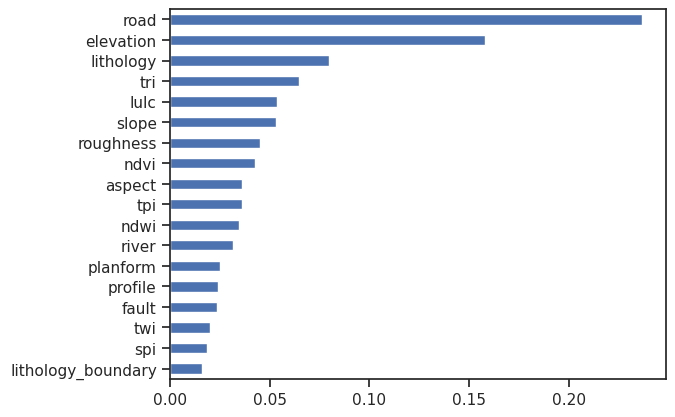

In [30]:
# Calculate Feature Importance: RF natively ranks features based on how much they contribute to reducing impurity (Gini index).
feat_importances = pd.Series(classifier.feature_importances_, index=X.columns)
# Plot the features sorted by importance (smallest/least important features at the bottom).
feat_importances.nsmallest(25).plot(kind='barh') 
plt.savefig(r'/workspace/fig/VY/feature_importance.png', bbox_inches='tight', dpi=600) # Save the feature importance plot.

**Predictors that have very little value for the model can be dropped**

**OPTION A: If you REMOVED any correlated predictor:**

In [ ]:
# IF you didnt drop any predictor after the Feature Importance step, skip these 2 lines of code bellow
data_selected = data.drop(columns=['tri']) # Final feature selection, put all predictors you want to remove (drop) after Feature Importance analysis
data_selected.head()

#Saving the final file for machine learning as .csv file
data_selected.to_csv('sample_points_VY(remove_collerated_data).csv', index = False)

IMPORTANT: You must also REMOVE the SAME exact predcitors from the **validation area's "sample_points.csv file"** to ensure consistency!

**OPTION B: If you kept ALL predictors (i.e., you didn't drop anything after analysis): Simply keep the 'sample_points.csv' and use for ML analysis in the next script**

In [ ]:
End.